# UNIVERSIDAD AUTÓNOMA METROPOLITANA UNIDAD IZTPALAPA <br>Licenciatura en Computación <br> Temas Selectos de Bases de Datos
## Proyecto Final
### Integrantes: 

- Alejandro Estrada Basilio (2203043898)
- Mariel Cielo Huerta
- Ricardo Palomino Bravo (2233013059)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df = pd.read_csv('Estatal-Víctimas-2015-2025_may2026.csv', encoding='latin1')

In [3]:
#copia del dataset
df_copia = df.copy()

In [4]:
df_copia.head()

,Año,Clave_Ent,Entidad,Bien jurídico afectado,Tipo de delito,Subtipo de delito,Modalidad,Sexo,Rango de edad,Enero,...,Marzo,Abril,Mayo,Junio,Julio,Agosto,Septiembre,Octubre,Noviembre,Diciembre
0,2015,1,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con arma de fuego,Mujer,Menores de edad (0-17),0,...,0,0,0,0,0,0,0,0,0,0
1,2015,1,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con arma blanca,Mujer,Menores de edad (0-17),0,...,0,0,0,0,0,0,0,0,0,0
2,2015,1,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con otro elemento,Mujer,Menores de edad (0-17),0,...,0,0,1,0,0,1,0,0,0,0
3,2015,1,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,No especificado,Mujer,Menores de edad (0-17),0,...,0,0,0,0,0,0,0,0,0,0
4,2015,1,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio culposo,Con arma de fuego,Mujer,Menores de edad (0-17),0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
df_copia.info()

<class 'pandas.DataFrame'>
RangeIndex: 80960 entries, 0 to 80959
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Año                     80960 non-null  int64
 1   Clave_Ent               80960 non-null  int64
 2   Entidad                 80960 non-null  str  
 3   Bien jurídico afectado  80960 non-null  str  
 4   Tipo de delito          80960 non-null  str  
 5   Subtipo de delito       80960 non-null  str  
 6   Modalidad               80960 non-null  str  
 7   Sexo                    80960 non-null  str  
 8   Rango de edad           80960 non-null  str  
 9   Enero                   80960 non-null  int64
 10  Febrero                 80960 non-null  int64
 11  Marzo                   80960 non-null  int64
 12  Abril                   80960 non-null  int64
 13  Mayo                    80960 non-null  int64
 14  Junio                   80960 non-null  int64
 15  Julio                   80960 

In [6]:
df_copia.tail()

,Año,Clave_Ent,Entidad,Bien jurídico afectado,Tipo de delito,Subtipo de delito,Modalidad,Sexo,Rango de edad,Enero,...,Marzo,Abril,Mayo,Junio,Julio,Agosto,Septiembre,Octubre,Noviembre,Diciembre
80955,2025,32,Zacatecas,Libertad personal,Otros delitos que atentan contra la libertad p...,Otros delitos que atentan contra la libertad p...,Otros delitos que atentan contra la libertad p...,No identificado,No identificado,0,...,0,0,0,0,2,2,0,0,0,0
80956,2025,32,Zacatecas,El patrimonio,Extorsión,Extorsión,Extorsión,No identificado,No identificado,0,...,2,1,0,0,0,0,1,0,0,2
80957,2025,32,Zacatecas,La sociedad,Corrupción de menores,Corrupción de menores,Corrupción de menores,No identificado,No identificado,1,...,1,0,1,0,1,0,0,0,0,1
80958,2025,32,Zacatecas,La sociedad,Trata de personas,Trata de personas,Trata de personas,No identificado,No identificado,0,...,0,0,2,0,0,0,0,0,0,0
80959,2025,32,Zacatecas,La sociedad,Otros delitos contra la sociedad,Otros delitos contra la sociedad,Otros delitos contra la sociedad,No identificado,No identificado,0,...,0,0,0,0,0,0,0,0,0,0


## Víctimas por mes en cada entidad a lo largo de 2015-2025

In [7]:
meses = ['Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio',
         'Julio', 'Agosto', 'Septiembre', 'Octubre', 'Noviembre', 'Diciembre']
resultado = df_copia.groupby('Entidad')[meses].sum().reset_index()
print(resultado)

                            Entidad  Enero  Febrero  Marzo  Abril   Mayo  \
0                    Aguascalientes   3976     4161   5007   4916   5270   
1                   Baja California  14914    14885  16840  16313  17441   
2               Baja California Sur   2339     2291   2708   2553   2775   
3                          Campeche   1768     1736   2085   1861   1978   
4                           Chiapas   3556     3429   3942   3693   3762   
5                         Chihuahua   8841     9477  10787  10537  12180   
6                  Ciudad de México  15000    15969  17765  16413  17202   
7              Coahuila de Zaragoza   4913     5553   6309   6168   6872   
8                            Colima   2625     2403   2854   2633   2746   
9                           Durango   3719     3912   4361   4169   4792   
10                       Guanajuato  18413    18334  21783  20427  22466   
11                         Guerrero   6585     6319   6932   6786   7432   
12          

In [8]:
df_copia.duplicated().sum() 

np.int64(0)

___

# 1. ¿Cuál fue la alteración de los delitos pre-pandemia, pandemia y post-pandemia?

Definimos los periodos de la siguiente manera: 

Pre-pandemia: 2015 - 2019 <br>
Pandemia: 2020 - 2021 <br>
Post-pandemia: 2022 - 2025 <br>

In [9]:
df_p1 = df.copy()

In [10]:
# Total de delitos por año 
df_p1['Total_anual'] = df_p1[meses].sum(axis=1)
totales_por_anio = df_p1.groupby('Año')['Total_anual'].sum().reset_index()

df_p1.head(10)
print(totales_por_anio)

     Año  Total_anual
0   2015       296318
1   2016       292812
2   2017       311565
3   2018       318749
4   2019       346275
5   2020       315570
6   2021       342320
7   2022       367065
8   2023       379169
9   2024       377251
10  2025       362450


In [11]:
# Clasificamos cada año en su periodo correspondiente
def clasificar_periodo(anio):
    if anio <= 2019:
        return 'Pre-pandemia'
    elif anio <= 2021:
        return 'Pandemia'
    else:
        return 'Post-pandemia'

In [12]:
totales_por_anio['Periodo'] = totales_por_anio['Año'].apply(clasificar_periodo)
print(totales_por_anio)

     Año  Total_anual        Periodo
0   2015       296318   Pre-pandemia
1   2016       292812   Pre-pandemia
2   2017       311565   Pre-pandemia
3   2018       318749   Pre-pandemia
4   2019       346275   Pre-pandemia
5   2020       315570       Pandemia
6   2021       342320       Pandemia
7   2022       367065  Post-pandemia
8   2023       379169  Post-pandemia
9   2024       377251  Post-pandemia
10  2025       362450  Post-pandemia


#### **La variación porcentual mide el aumento o disminución de un valor respecto a su punto de partida en términos de porcentaje.**

*Variación Porcentual = (Valor Final - Valor Inicial) / Valor Inicial * 100*

In [13]:
# Promedio anual de delitos por periodo
promedio_periodo = totales_por_anio.groupby('Periodo')['Total_anual'].mean().reindex(
    ['Pre-pandemia', 'Pandemia', 'Post-pandemia'])
print(promedio_periodo)

# Variación porcentual entre periodos
variacion_pandemia = (promedio_periodo['Pandemia'] - promedio_periodo['Pre-pandemia']) / promedio_periodo['Pre-pandemia'] * 100
variacion_post = (promedio_periodo['Post-pandemia'] - promedio_periodo['Pandemia']) / promedio_periodo['Pandemia'] * 100

print(f"\nVariación pre-pandemia -> pandemia: {variacion_pandemia:.2f}%")
print(f"Variación pandemia -> post-pandemia: {variacion_post:.2f}%")

Periodo
Pre-pandemia     313143.80
Pandemia         328945.00
Post-pandemia    371483.75
Name: Total_anual, dtype: float64

Variación pre-pandemia -> pandemia: 5.05%
Variación pandemia -> post-pandemia: 12.93%


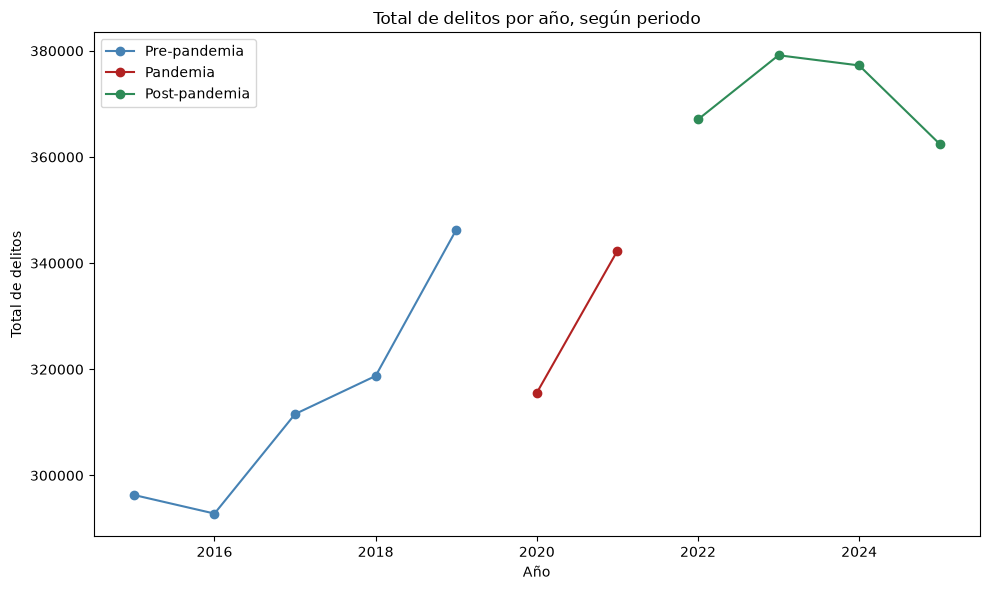

In [14]:
# Gráfica de línea por año, coloreada por periodo
plt.figure(figsize=(10, 6))
colores = {'Pre-pandemia': 'steelblue', 'Pandemia': 'firebrick', 'Post-pandemia': 'seagreen'}
for periodo in ['Pre-pandemia', 'Pandemia', 'Post-pandemia']:
    subset = totales_por_anio[totales_por_anio['Periodo'] == periodo]
    plt.plot(subset['Año'], subset['Total_anual'], marker='o', label=periodo, color=colores[periodo])

plt.title('Total de delitos por año, según periodo')
plt.xlabel('Año')
plt.ylabel('Total de delitos')
plt.legend()
plt.tight_layout()
plt.show()

___

# 3. ¿Cuál es el delito más común experimentado por las victimas?

*Transformamos una copia del dataset para que podamos trabajar adecuadamente, luego transformaremos todas las columnas correspondientes a los meses en una nueva columna que muestra los meses y cada mes se vuelva una fila.*

In [15]:
#Realizamos una copia del dataframe por cada pregunta
df_p3 = df.copy()

# Identificamos el resto de las columnas que se van a quedar intactas como Año, Entidad, etc.
columnas_fijas = [col for col in df.columns if col not in meses]

# Aplicamos pd.melt() para transformar las columnas de mes en filas
df_limpio_p3 = pd.melt(
    df_p3, 
    id_vars = columnas_fijas,  # Las columnas que no se mueven
    value_vars = meses,        # Las columnas que se van a convertir en filas
    var_name = 'Mes',          # El nombre de la nueva columna que guardará los meses
    value_name = 'Total_Victimas' # El nombre de la nueva columna que guardará los conteos numéricos
)

# 5. Visualizamos el resultado
df_limpio_p3.head()

,Año,Clave_Ent,Entidad,Bien jurídico afectado,Tipo de delito,Subtipo de delito,Modalidad,Sexo,Rango de edad,Mes,Total_Victimas
0,2015,1,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con arma de fuego,Mujer,Menores de edad (0-17),Enero,0
1,2015,1,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con arma blanca,Mujer,Menores de edad (0-17),Enero,0
2,2015,1,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con otro elemento,Mujer,Menores de edad (0-17),Enero,0
3,2015,1,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,No especificado,Mujer,Menores de edad (0-17),Enero,0
4,2015,1,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio culposo,Con arma de fuego,Mujer,Menores de edad (0-17),Enero,0


In [16]:
# Agrupamos por 'Tipo de delito' y sumamos todas las víctimas de todos los años, meses y estados
delitos_agrupados = df_limpio_p3.groupby('Tipo de delito')['Total_Victimas'].sum()

# Ordenamos los resultados de mayor a menor 
delitos_top = delitos_agrupados.sort_values(ascending=False)

# Lo convertimos a un DataFrame para que se vea como una tabla bonita y mostramos el Top 10
tabla_top_10 = delitos_top.head(10).reset_index()

# Imprimimos la tabla
print("Los delitos más comunes experimentados por las victimas son:")
tabla_top_10


Los delitos más comunes experimentados por las victimas son:


,Tipo de delito,Total_Victimas
0,Lesiones,2568337
1,Homicidio,518338
2,Otros delitos que atentan contra la libertad p...,260265
3,Otros delitos que atentan contra la vida y la ...,124707
4,Extorsión,96026
5,Otros delitos contra la sociedad,70368
6,Corrupción de menores,30175
7,Secuestro,12327
8,Feminicidio,9166
9,Trata de personas,9019


C:\Users\alexh\AppData\Local\Temp\ipykernel_13660\3759639872.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  grafico = sns.barplot(x=top_5.values, y=top_5.index, palette='viridis')


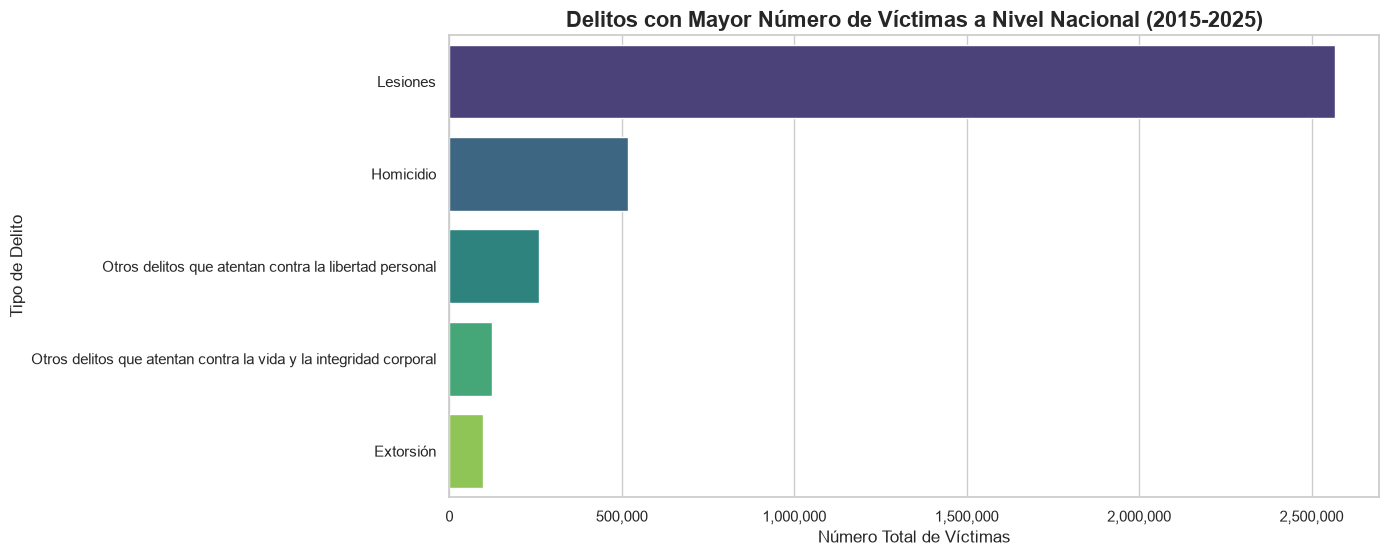

In [17]:
# Configuramos el estilo y tamaño del gráfico
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# Tomamos solo el Top 5 para que la gráfica no se sature
top_5 = delitos_top.head(5)

# Creamos el gráfico de barras horizontales
grafico = sns.barplot(x=top_5.values, y=top_5.index, palette='viridis')

# Ponemos los títulos
plt.title('Delitos con Mayor Número de Víctimas a Nivel Nacional (2015-2025)', fontsize=16, fontweight='bold')
plt.xlabel('Número Total de Víctimas', fontsize=12)
plt.ylabel('Tipo de Delito', fontsize=12)

# Formateamos los números del eje X para que tengan comas (ej. 1,000,000)
grafico.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

plt.show()

### *Observemos además: ¿Los dos delitos más cometidos a víctimas son accidentales o intencionales?*

* ***Delito Doloso***: aquel que se comete con plena intención, conocimiento y voluntad.

* ***Delito Culposo***: aquel que al cometerse no existe la intención de causar un daño, pero el resultado se produce debido a negligencia, imprudencia, impericia o inobservancia de las leyes.

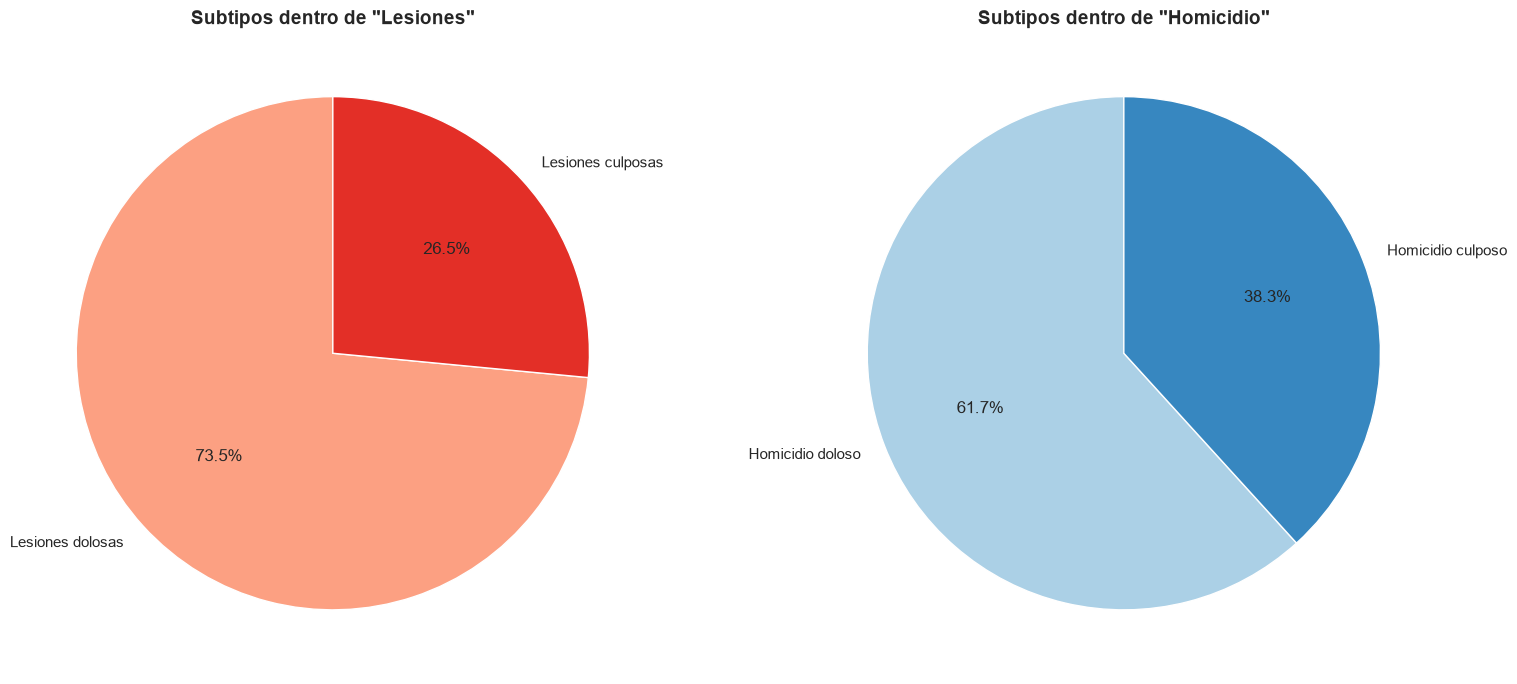

In [18]:
# Proporciones por Subtipo de Delito
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# --- GRÁFICO 1: LESIONES ---
# Filtramos solo las Lesiones y agrupamos por Subtipo
df_lesiones = df_limpio_p3[df_limpio_p3['Tipo de delito'] == 'Lesiones']
sub_lesiones = df_lesiones.groupby('Subtipo de delito')['Total_Victimas'].sum().sort_values(ascending=False)

# Dibujamos el pastel (Usamos una paleta de tonos Rojos)
axes[0].pie(sub_lesiones, labels=sub_lesiones.index, autopct='%1.1f%%', 
            startangle=90, colors=sns.color_palette("Reds", len(sub_lesiones)))
axes[0].set_title('Subtipos dentro de "Lesiones"', fontweight='bold', fontsize=14)

# --- GRÁFICO 2: HOMICIDIO ---
# Filtramos solo los Homicidios y agrupamos por Subtipo
df_homicidio = df_limpio_p3[df_limpio_p3['Tipo de delito'] == 'Homicidio']
sub_homicidio = df_homicidio.groupby('Subtipo de delito')['Total_Victimas'].sum().sort_values(ascending=False)

# Dibujamos el pastel (Usamos una paleta de tonos Azules)
axes[1].pie(sub_homicidio, labels=sub_homicidio.index, autopct='%1.1f%%', 
            startangle=90, colors=sns.color_palette("Blues", len(sub_homicidio)))
axes[1].set_title('Subtipos dentro de "Homicidio"', fontweight='bold', fontsize=14)

plt.tight_layout()
plt.show()

#### *Los dos tipos de delito más comunes perpetrados a las victimas **son en su mayoría premeditados o hechos con saña, alevosía y/o ventaja.***

_____

# 4. ¿Cuál es el estado con más victimas desde 2015 hasta 2025?

In [19]:
df_p4 = df.copy()
resultado = df_p4.groupby('Entidad')[meses].sum().reset_index()

In [20]:
# Sumamos los 12 meses para obtener el total de incidencias por estado
resultado['Total'] = resultado[meses].sum(axis=1) #axis = 1 suma horizontalmente 

# Ordenamos de mayor a menor
resultado_ordenado = resultado.sort_values('Total', ascending=False) #(ascending = false) = descending
print(resultado_ordenado[['Entidad', 'Total']])

# El estado con más incidencias que será el que esté en primer lugar, peuesto que ya ordenamos 
estado_max = resultado_ordenado.iloc[0] 
print(f"\nEl estado con más incidencias delictivas es {estado_max['Entidad']} con {estado_max['Total']} víctimas registradas.")

                            Entidad   Total
16                           México  871069
10                       Guanajuato  245881
1                   Baja California  203057
13                          Jalisco  202384
6                  Ciudad de México  198022
18                       Nuevo León  172920
29  Veracruz de Ignacio de la Llave  142418
5                         Chihuahua  131416
14              Michoacán de Ocampo  127493
20                           Puebla  107887
21                        Querétaro   99009
12                          Hidalgo   98245
19                           Oaxaca   93525
26                          Tabasco   86750
24                          Sinaloa   84260
27                       Tamaulipas   81365
11                         Guerrero   79323
22                     Quintana Roo   74134
15                          Morelos   73945
7              Coahuila de Zaragoza   73687
23                  San Luis Potosí   68837
25                           Son

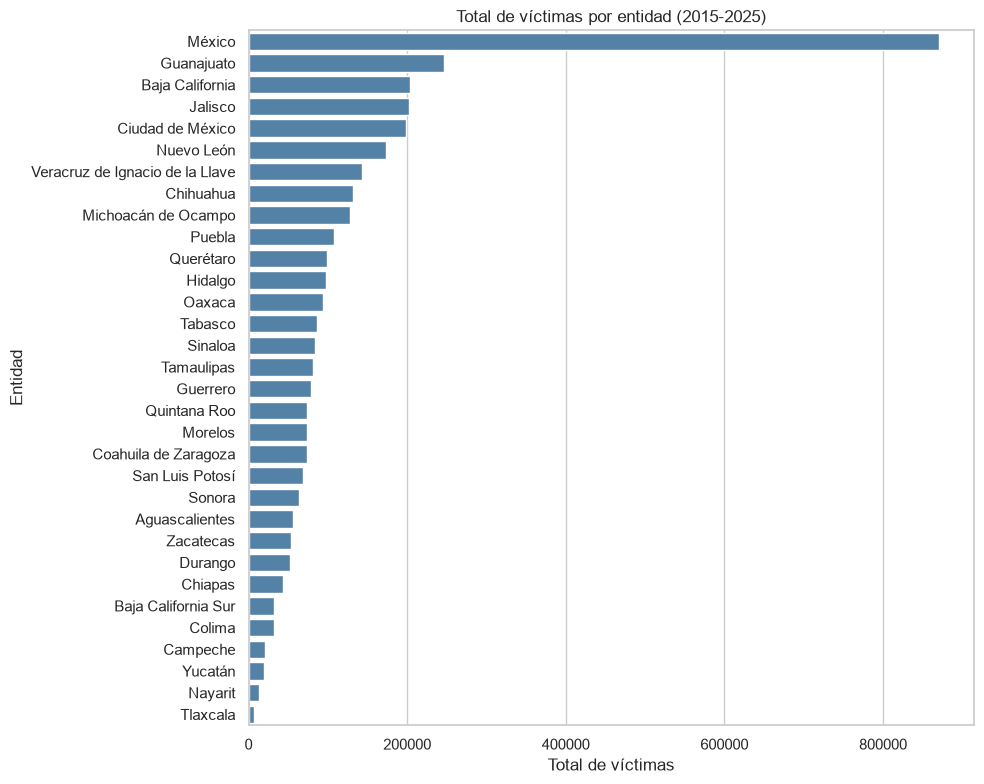

In [21]:
# Gráfica de barras para visualizar el ranking
plt.figure(figsize=(10, 8))
sns.barplot(data=resultado_ordenado, x='Total', y='Entidad', color='steelblue')
plt.title('Total de víctimas por entidad (2015-2025)')
plt.xlabel('Total de víctimas')
plt.ylabel('Entidad')
plt.tight_layout()

_____

# 6. ¿Hay algún mes en donde los delitos contra las victimas sea mayor? 

*A continuación mostramos el pico máximo de los delitos más comunes asociados al mes en donde historicamente hubo más ocurrencias de dichos delitos*


In [22]:
# Agrupamos sumando por año para tener el total nacional mensual de TODOS los delitos a la vez
nacional_todos = df_limpio_p3.groupby(['Año', 'Mes', 'Tipo de delito'])['Total_Victimas'].sum().reset_index()

# Calculamos el PROMEDIO histórico de cada mes para cada delito
promedio_delitos = nacional_todos.groupby(['Tipo de delito', 'Mes'])['Total_Victimas'].mean().reset_index()

#  Buscamos el índice del valor máximo para cada delito
# .idxmax() encuentra en qué fila está el valor más alto (el pico) de cada grupo
indices_picos = promedio_delitos.groupby('Tipo de delito')['Total_Victimas'].idxmax()

# Usamos esos índices para filtrar nuestra tabla y quedarnos SOLO con los meses pico
meses_pico = promedio_delitos.loc[indices_picos]

# Ordenamos de mayor a menor impacto y renombramos la columna para que sea clara
meses_pico = meses_pico.sort_values(by='Total_Victimas', ascending=False)
meses_pico.rename(columns={'Total_Victimas': 'Promedio_Maximo_Mensual'}, inplace=True)



#  Filtramos aquellos que tienen 0 víctimas (delitos que no ocurren) y mostramos el Top 15
meses_pico = meses_pico[meses_pico['Promedio_Maximo_Mensual'] > 0]
meses_pico.head(15).reset_index(drop=True)
print("-> Notamos que el mes de MAYO, es el mes donde más ocurrencias hay de 4 tipos de delito")
print("-> Además MAYO, es el més donde ocurren los dos delitos más comunes")


-> Notamos que el mes de MAYO, es el mes donde más ocurrencias hay de 4 tipos de delito
-> Además MAYO, es el més donde ocurren los dos delitos más comunes


*Como pudimos ver, el mes de MAYO tiene el lugar como el mes donde 3 de los delitos más comunes presentan máximos históricos a lo largo del periodo del tiempo reportado. ¿Y si observamos el comportamiento general de los delitos en los meses de MAYO desde 2015 hasta 2025?*

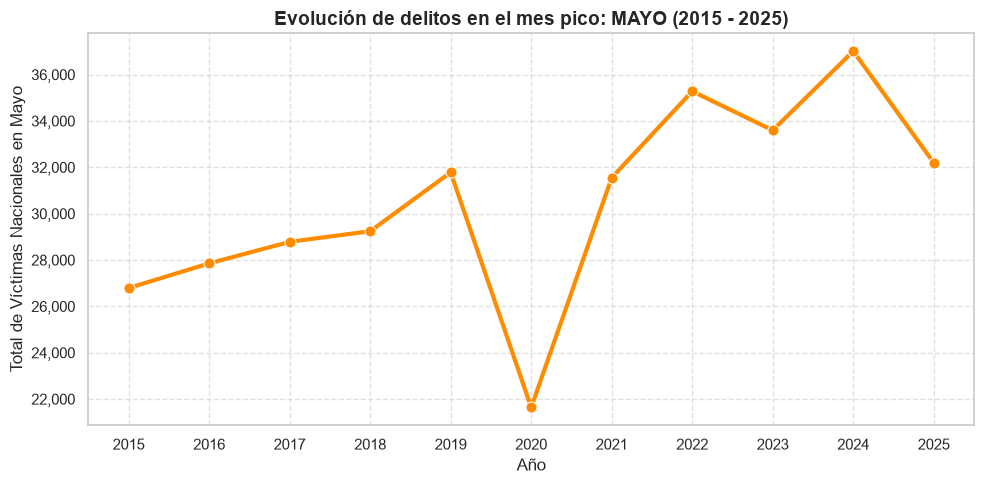

In [23]:
# Tendencia Histórica de los meses de Mayo
# Filtramos el dataset para quedarnos SOLAMENTE con los meses de Mayo
df_mayo = df_limpio_p3[df_limpio_p3['Mes'] == 'Mayo']

# Sumamos el total de todos los delitos a nivel nacional agrupado por Año
mayo_historico = df_mayo.groupby('Año')['Total_Victimas'].sum().reset_index()

# Graficamos la tendencia en el tiempo
plt.figure(figsize=(10, 5))
grafico_mayo = sns.lineplot(data=mayo_historico, x='Año', y='Total_Victimas', 
                            marker='o', color='darkorange', linewidth=3, markersize=8)

plt.title('Evolución de delitos en el mes pico: MAYO (2015 - 2025)', fontweight='bold', fontsize=14)
plt.xlabel('Año', fontsize=12)
plt.ylabel('Total de Víctimas Nacionales en Mayo', fontsize=12)

# Formateo visual (Poner comas al eje Y, y forzar que el eje X muestre todos los años)
grafico_mayo.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, loc: "{:,}".format(int(y))))
plt.xticks(mayo_historico['Año']) # Muestra 2015, 2016, 2017... sin decimales

plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### **¿Por qué los delitos relacionados con agresiones físicas son perpetrados mayormente a este mes?**